In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
# show first 5 rows
df.head()  

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
#Data Overview & Structure

In [6]:
# Check dataset shape
print(df.shape)

(545, 13)


In [7]:
#check dataset colums
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [8]:
# Check dataset basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [9]:
# Identify missing/null values in dataset
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
# Convert binary categorical features into numerical format
binary_cols = ['mainroad', 'guestroom', 'basement', 
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [11]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [12]:
# Verify binary conversion
df[binary_cols].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [13]:
# Apply one-hot encoding for multi-category column
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [14]:
# Show only encoded columns
df.filter(like='furnishingstatus').head()

,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False


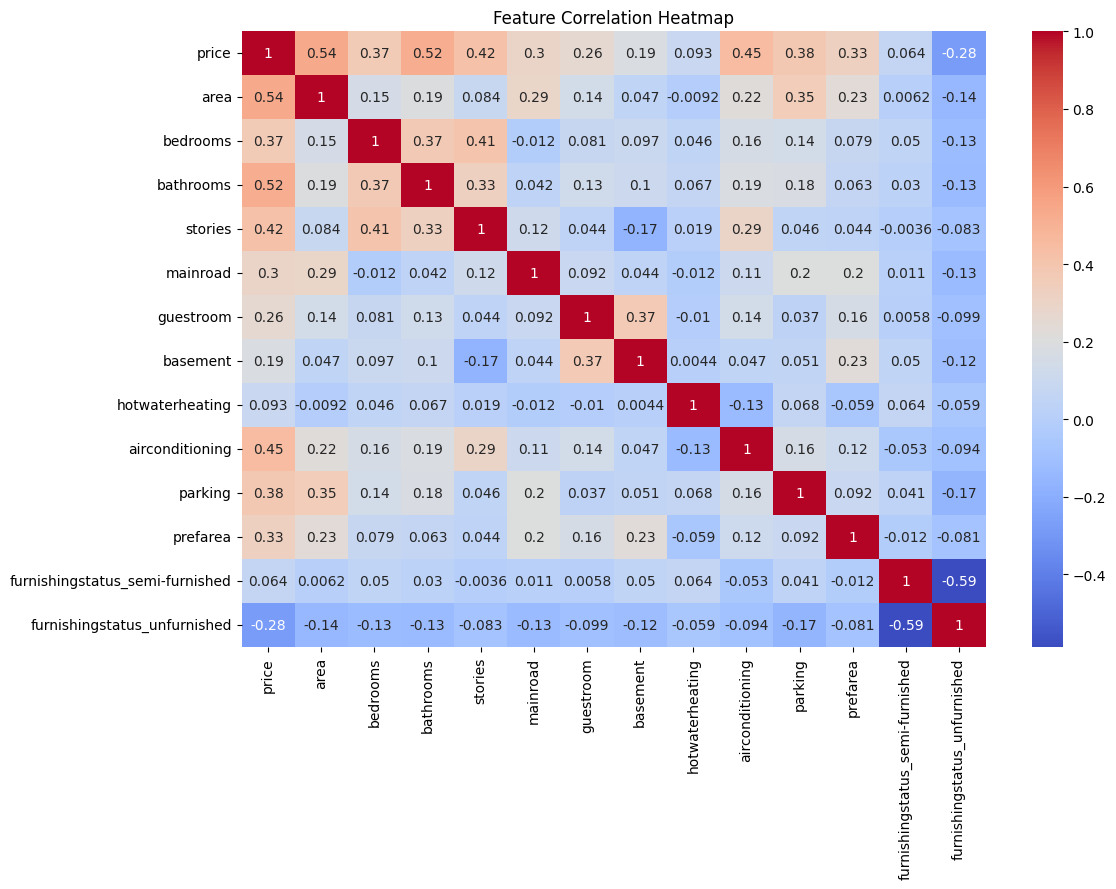

In [15]:
# Visualize correlation between features using heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))  # set figure size
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')  # correlation plot
plt.title("Feature Correlation Heatmap")
plt.show()

## 📊 Heatmap Analysis 

- Dark red → strong positive correlation  
- Light red → moderate correlation  
- Blue → negative correlation  
- Light color → weak correlation  

- Area shows strong correlation with price  
- Bathrooms show moderate correlation  
- Parking shows weak correlation  

- Overall, area is the most important feature  

In [16]:
# Define input features (X) and target variable (y)
X = df.drop('price', axis=1)   # all columns except price
y = df['price']                # target variable

In [17]:
# Check shapes of features and target
print(X.shape)
print(y.shape)

(545, 13)
(545,)


## 📊 Feature Selection

- X contains all independent variables (features)  
- y contains the target variable (price)  
- Model will learn relationship between X and y  

In [18]:
# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
# Check shapes of split data
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(436, 13)
(109, 13)
(436,)
(109,)


## 📊 Train-Test Split

- Dataset is divided into training and testing sets  
- 80% data used for training  
- 20% data used for testing  
- Ensures model is evaluated on unseen data  

In [21]:
# Train Linear Regression model on training data
from sklearn.linear_model import LinearRegression

model = LinearRegression()   # create model
model.fit(X_train, y_train)  # train model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
# Check model coefficients and intercept
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 260032.35760740936
Coefficients: [ 2.35968805e+02  7.67787016e+04  1.09444479e+06  4.07476595e+05
  3.67919948e+05  2.31610037e+05  3.90251176e+05  6.84649885e+05
  7.91426736e+05  2.24841913e+05  6.29890565e+05 -1.26881818e+05
 -4.13645062e+05]


## 📊 Model Training

- Linear Regression model is trained on training data  
- Model learns relationship between features and price  
- Coefficients represent importance of each feature  

In [23]:
# Predict house prices using test data
predictions = model.predict(X_test)

In [24]:
# View first 5 predicted values
print(predictions[:5])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.3272256
 3294646.25725955]


In [25]:
# Compare actual and predicted prices
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': predictions
})

comparison.head()

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06


## 📊 Prediction

- Model is used to predict house prices on test data  
- Predicted values are compared with actual prices  
- Helps evaluate model performance  

In [26]:
# Evaluate model performance using error metrics
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)   # calculate MSE
r2 = r2_score(y_test, predictions)              # calculate R2 score

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1754318687330.6626
R2 Score: 0.6529242642153186


## 📊 Model Evaluation

- Mean Squared Error (MSE) measures prediction error  
- Lower MSE indicates better performance  
- R² score shows model accuracy  
- Higher R² value (closer to 1) indicates better model fit  

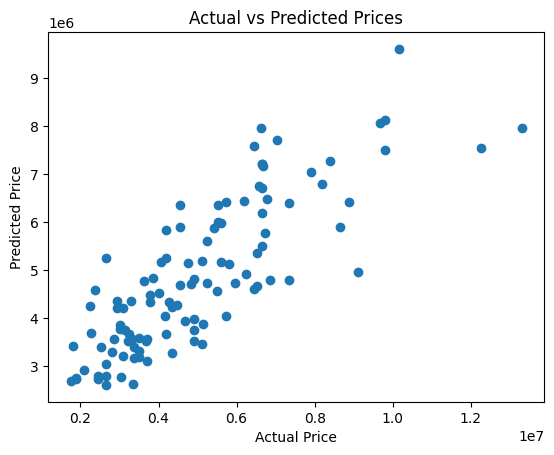

In [27]:
# Plot actual vs predicted house prices
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)   # scatter plot
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

## 📊 Actual vs Predicted Analysis

- Scatter plot compares actual and predicted prices  
- Points close to diagonal line indicate good predictions  
- Some variation shows prediction error  
- Overall model shows reasonable accuracy  

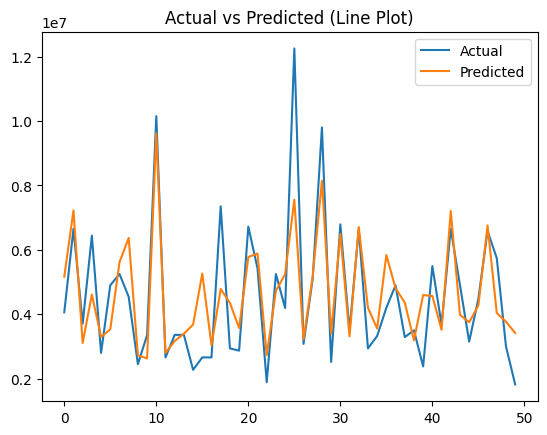

In [28]:
# Plot first 50 actual vs predicted values
plt.plot(y_test.values[:50], label='Actual')
plt.plot(predictions[:50], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted (Line Plot)")
plt.show()

In [29]:
# Check correlation of all features with price
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

<Axes: xlabel='price'>

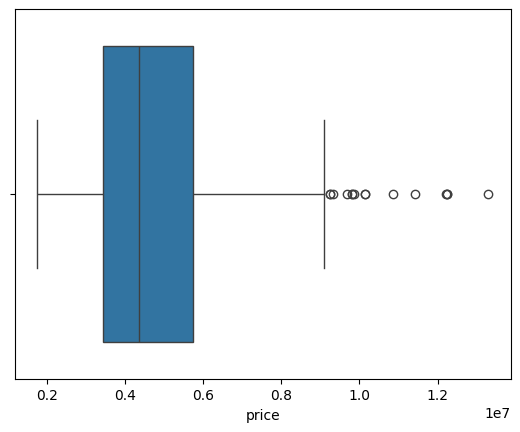

In [30]:
# Detect outliers in price
sns.boxplot(x=df['price'])

<Axes: xlabel='price', ylabel='Count'>

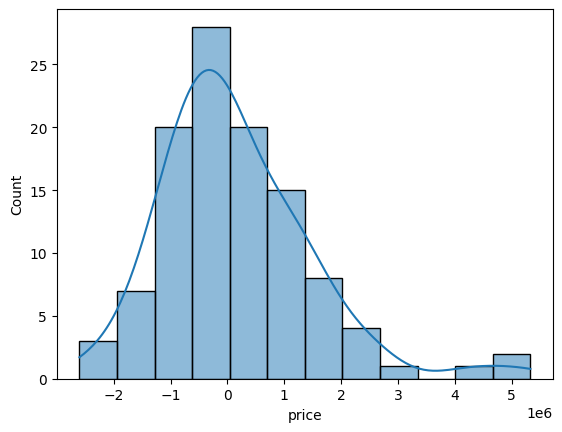

In [31]:
# Calculate residuals (actual - predicted)
residuals = y_test - predictions

# Plot residual distribution
import seaborn as sns
sns.histplot(residuals, kde=True)

In [32]:
# Analyze importance of each feature using model coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

feature_importance.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04
